# Additional EDA


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
sns.set_theme(style="whitegrid")
Path("eda_figures").mkdir(exist_ok=True)

In [2]:
# Data loads from the repo's data/ folder via the DengAI package, so this runs
# regardless of which directory the kernel was started in.
from DengAI import load_raw

df_train_features, df_train_labels, _ = load_raw()

# EDA setup


In [3]:
df_eda = df_train_features.merge(
    df_train_labels,
    on=["city", "year", "weekofyear"],
    validate="one_to_one",
)
df_eda["week_start_date"] = pd.to_datetime(df_eda["week_start_date"])
df_eda = df_eda.sort_values(["city", "week_start_date"])

sj_eda = df_eda.query("city == 'sj'").copy()
iq_eda = df_eda.query("city == 'iq'").copy()

In [4]:
summary = df_eda.groupby("city")["total_cases"].describe()
display(summary.round(2))

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
iq,520.0,7.57,10.77,0.0,1.0,5.0,9.0,116.0
sj,936.0,34.18,51.38,0.0,9.0,19.0,37.0,461.0


## Weekly cases

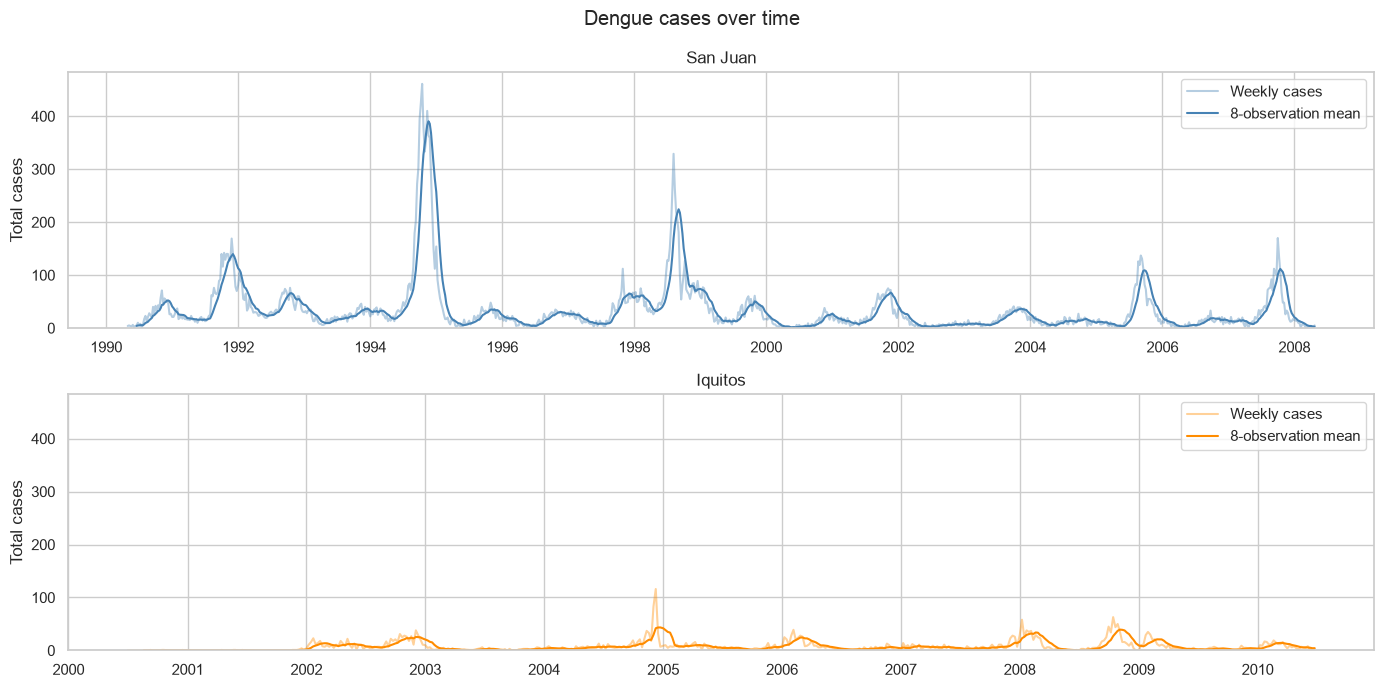

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharey=True)

for ax, df, city, color in zip(axes, [sj_eda, iq_eda], ["San Juan", "Iquitos"], ["steelblue", "darkorange"]):
    ax.plot(df["week_start_date"], df["total_cases"], color=color, alpha=0.4, label="Weekly cases")
    ax.plot(df["week_start_date"], df["total_cases"].rolling(8).mean(), color=color, label="8-observation mean")
    ax.set_title(city)
    ax.set_ylabel("Total cases")
    ax.set_ylim(bottom=0)
    ax.legend()

fig.suptitle("Dengue cases over time")
plt.tight_layout()
plt.savefig("eda_figures/weekly_cases.png", dpi=250, bbox_inches="tight")
plt.show()

## Seasonality

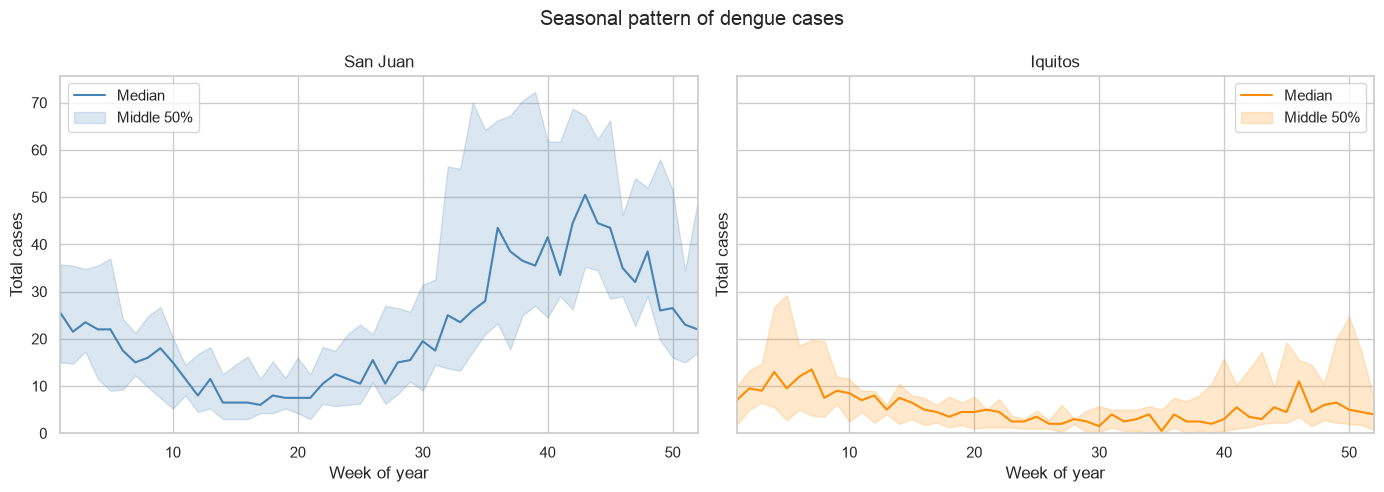

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, df, city, color in zip(axes, [sj_eda, iq_eda], ["San Juan", "Iquitos"], ["steelblue", "darkorange"]):
    weekly_cases = df.query("weekofyear <= 52").groupby("weekofyear")["total_cases"] # Week 53 is omitted here because it occurs less often.

    median = weekly_cases.median()
    lower = weekly_cases.quantile(0.25)
    upper = weekly_cases.quantile(0.75)

    ax.plot(median.index, median, color=color, label="Median")
    ax.fill_between(median.index, lower, upper, color=color, alpha=0.2, label="Middle 50%")
    ax.set_title(city)
    ax.set_xlabel("Week of year")
    ax.set_ylabel("Total cases")
    ax.set_xlim(1, 52)
    ax.set_ylim(bottom=0)
    ax.legend()

fig.suptitle("Seasonal pattern of dengue cases")
plt.tight_layout()
plt.savefig("eda_figures/seasonality.png", dpi=250, bbox_inches="tight")
plt.show()

San Juan tends to have higher counts later in the year, while Iquitos has higher medians near the beginning. This supports exploring seasonal features separately for the cities.

## Weather and cases

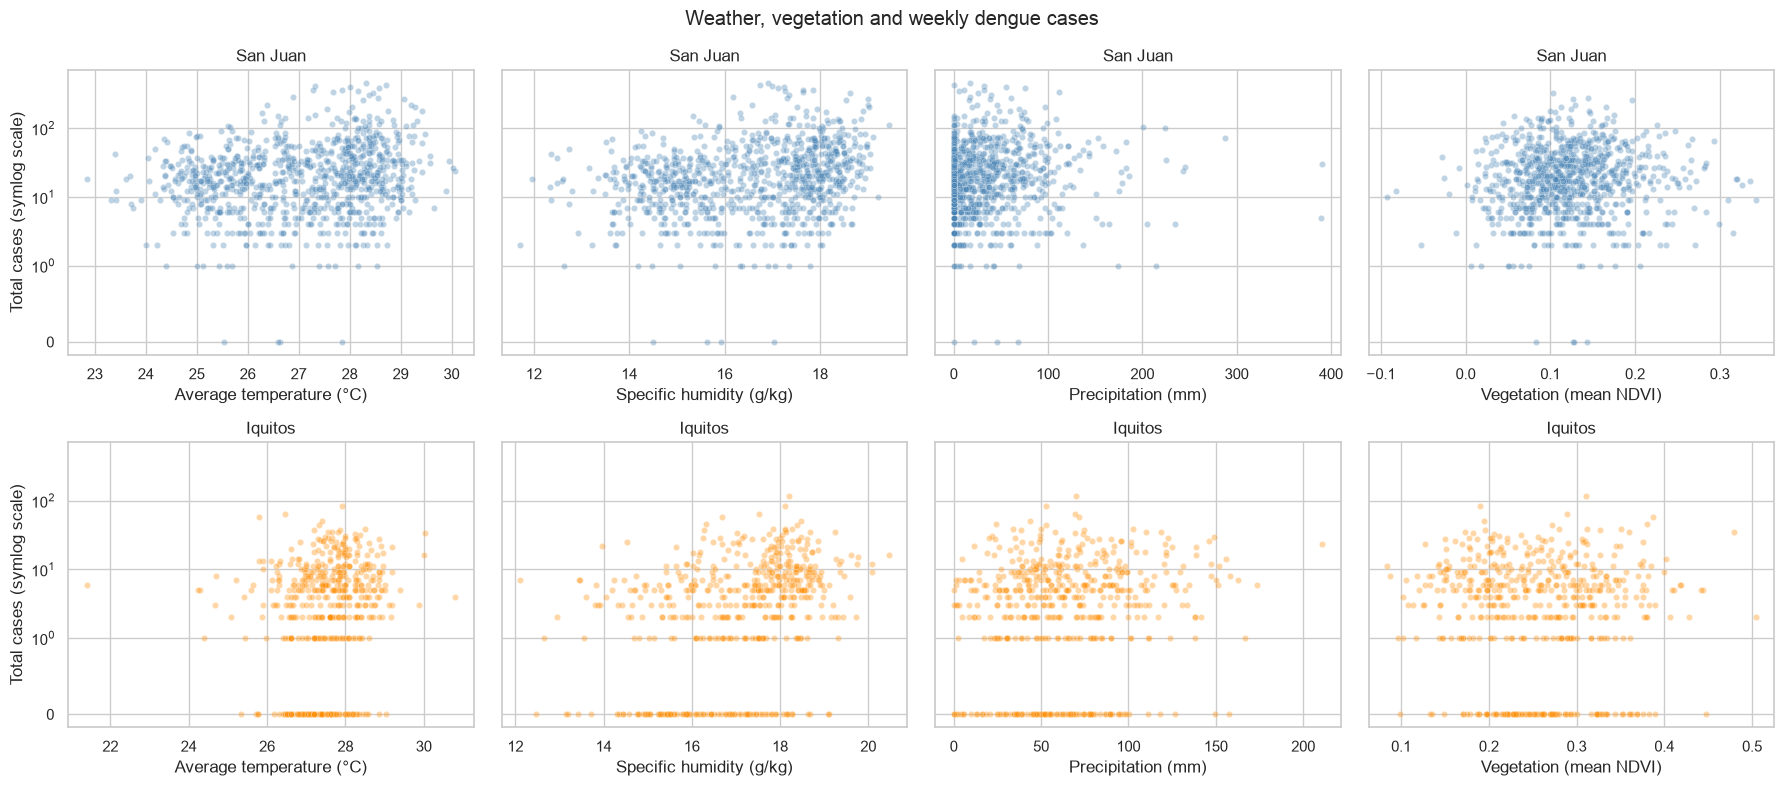

In [7]:
ndvi_columns = ["ndvi_ne", "ndvi_nw", "ndvi_se", "ndvi_sw"]

weather_columns = [
    "station_avg_temp_c",
    "reanalysis_specific_humidity_g_per_kg",
    "precipitation_amt_mm",
    "ndvi_mean",
]
weather_labels = ["Average temperature (°C)", "Specific humidity (g/kg)", "Precipitation (mm)", "Vegetation (mean NDVI)"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)

for row, df, city, color in zip(range(2), [sj_eda, iq_eda], ["San Juan", "Iquitos"], ["steelblue", "darkorange"]):
    df = df.copy()
    df["ndvi_mean"] = df[ndvi_columns].mean(axis=1)

    for col, feature in enumerate(weather_columns):
        ax = axes[row, col]
        sns.scatterplot(data=df, x=feature, y="total_cases", ax=ax,
                        color=color, alpha=0.35, s=20)
        ax.set_title(city)
        ax.set_xlabel(weather_labels[col])
        ax.set_ylabel("Total cases (symlog scale)")
        ax.set_yscale("symlog", linthresh=1)

fig.suptitle("Weather, vegetation and weekly dengue cases")
plt.tight_layout()
plt.savefig("eda_figures/weather_relationships.png", dpi=250, bbox_inches="tight")
plt.show()

## Missing values

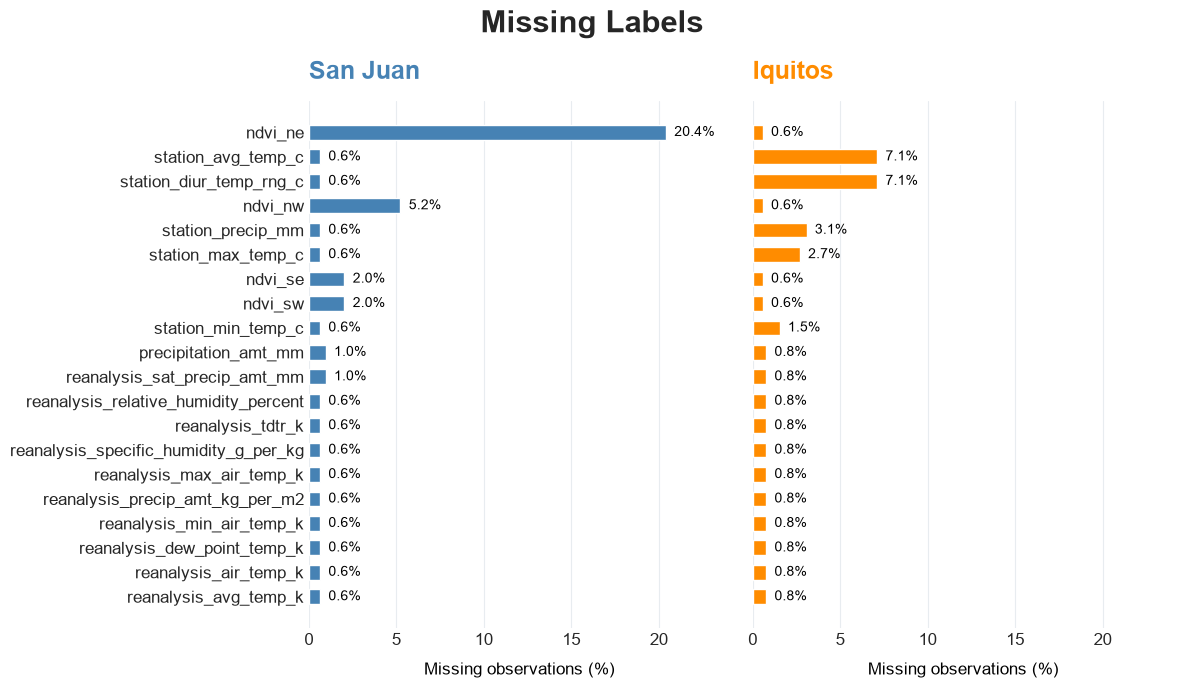

In [8]:
missing = pd.DataFrame({
    "San Juan": sj_eda.isna().mean() * 100,
    "Iquitos": iq_eda.isna().mean() * 100,
})
top_features = missing.max(axis=1).sort_values(ascending=False)
top_features = top_features[top_features > 0].index
missing = missing.loc[top_features]

fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharex=True, sharey=True)
fig.patch.set_facecolor("white")

for ax, city, color in zip(axes, missing.columns, ["steelblue", "darkorange"]):
    bars = ax.barh(missing.index, missing[city], color=color, height=0.6)
    ax.bar_label(bars, labels=[f"{value:.1f}%" for value in missing[city]], padding=6, fontsize=10, color="black")
    ax.set_title(city, loc="left", fontsize=18, fontweight="bold", color=color, pad=16)
    ax.set_xlabel("Missing observations (%)", labelpad=10, color="black")
    ax.set_xlim(0, missing.max().max() * 1.18)
    ax.grid(axis="x", color="#E8ECF0", linewidth=0.8)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", length=0, labelsize=12)
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].invert_yaxis()
fig.suptitle("Missing Labels", fontsize=22, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_figures/missingness.png", dpi=250, bbox_inches="tight", facecolor="white")
plt.show()

## Weather lags

Compare earlier weather and vegetation with current cases using Spearman correlation. A lag of 4 means four rows earlier, approximately four weeks.

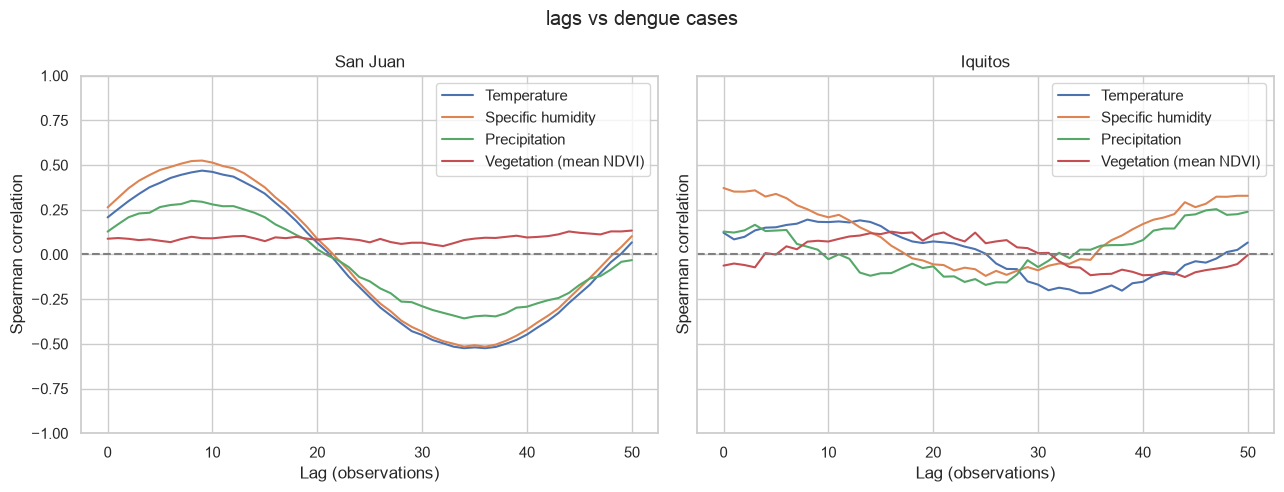

In [9]:
lag_columns = [
    "reanalysis_air_temp_k",
    "reanalysis_specific_humidity_g_per_kg",
    "precipitation_amt_mm",
    "ndvi_mean",
]
lag_labels = ["Temperature", "Specific humidity", "Precipitation", "Vegetation (mean NDVI)"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for ax, df, city in zip(axes, [sj_eda, iq_eda], ["San Juan", "Iquitos"]):
    df = df.copy()
    df["ndvi_mean"] = df[["ndvi_ne", "ndvi_nw", "ndvi_se", "ndvi_sw"]].mean(axis=1)
    for feature, label in zip(lag_columns, lag_labels):
        correlations = []
        for lag in range(51):
            pairs = pd.DataFrame({
                "weather": df[feature].shift(lag),
                "cases": df["total_cases"],
            }).dropna()
            # Correlation of ranks gives Spearman correlation.
            correlations.append(pairs["weather"].rank().corr(pairs["cases"].rank()))
        ax.plot(range(51), correlations, label=label)

    ax.axhline(0, color="gray", linestyle="--")
    ax.set_title(city)
    ax.set_xlabel("Lag (observations)")
    ax.set_ylabel("Spearman correlation")
    ax.set_ylim(-1, 1)
    ax.legend()

fig.suptitle("lags vs dengue cases")
plt.tight_layout()
plt.savefig("eda_figures/lag_correlations.png", dpi=250, bbox_inches="tight")
plt.show()